# Multi-temperature permeation: Chebyshev vs. FESTIM, with Richardson extrapolation

`permeation_compare.ipynb` showed Chebyshev pseudospectral collocation
hitting geometric convergence on a constant-T permeation problem with an
analytical solution, beating FESTIM P1/P2/P3, and used Richardson
extrapolation in time to push below the backward-Euler error floor.

This notebook extends the same comparison to a regime where there is no
analytical solution: gas-driven permeation with two McNabb-Foster traps
where the temperature schedule cycles down by 100 K steps and back up.
FESTIM P1 has historically diverged on the deeper-step versions of this
problem; Chebyshev keeps converging.

For each of three schedules of increasing severity (1, 2, 3 steps down
and back up) the notebook produces:

1. rel-L2 vs spatial DOFs, with four series (Chebyshev BE, Chebyshev
   Richardson, FESTIM P1 BE, FESTIM P1 Richardson) and a BE-plateau
   reference line.
2. Wall time vs rel-L2 (efficiency frontier) with the same four series.

The reference solution is a high-resolution Chebyshev solve at very
small time step (`MAX_DT/16`), per schedule. The BE plateau per schedule
is a half-step comparison at the same high N.


## 1. Physical constants

Tungsten substrate, single mobile H species, two trapping reactions
matching the PTTEP `timelag_analysis_functions.py`. Run pressure is
1 bar; bake pressure is 0 Pa with a 20-min cosine ramp from one to
the other. `RUN_LENGTH_MAP` is sized so each segment lasts roughly
`3 * L^2 / D(T)` (long enough for the flux to approach steady state at
that temperature). The 400 K entry is the new addition for the 3-step
schedule.


In [1]:
import os
import time
import math
import contextlib

import numpy as np
import matplotlib.pyplot as plt
import ufl

import festim as F
import chebyshev_festim as CF

FIG_DIR = os.path.join("..", "figs")
os.makedirs(FIG_DIR, exist_ok=True)

print("FESTIM :", F.__version__)


FESTIM : 2.0a7


In [2]:
SUBSTRATE_THICK = 1e-3                       # m
W_ATOM_DENSITY  = 6.3e28                     # atom/m^3
P_RUN, P_BAKE   = 1.0e5, 0.0                 # Pa
DECREASE_TIME   = 1200.0                     # s, sinusoidal ramp duration

# tungsten transport (Frauenfelder)
D_0,  E_D    = 4.1e-7, 0.39                  # m^2/s, eV
K_S_0, E_K_S = 1.87e24, 1.04                 # H/m^3/Pa^0.5, eV

# trap parameters (matches PTTEP timelag_analysis_functions.py)
N_TRAP1   = 1.3e-3 * W_ATOM_DENSITY
N_TRAP2   = 4e-4   * W_ATOM_DENSITY
K_0_TRAP  = 4.1e-7 / (1.1e-10**2 * 6 * W_ATOM_DENSITY)
E_K_TRAP  = 0.39
P_0_TRAP  = 1e13
E_P_TRAP1 = 0.87
E_P_TRAP2 = 1.0

# Run-length map: ~3 * L^2 / D(T) at each temperature, snapped clean.
RUN_LENGTH_MAP = {
    700: 6.0e3,
    600: 3.0e4,
    500: 6.0e4,
    400: 4.0e5,
}
BAKE_MULT = 1.5

# Time-step controller and reference settings
MAX_DT          = 200.0      # s; cap on BE step in test sweeps
DT_REF_DIVISOR  = 16         # reference dt = MAX_DT / DT_REF_DIVISOR
QUALITY_GATE    = 0.2        # rel-L2 above this is silent divergence

print(f"L = {SUBSTRATE_THICK*1e3:.2f} mm")
print(f"trap1 dens = {N_TRAP1:.2e}  E_p = {E_P_TRAP1} eV")
print(f"trap2 dens = {N_TRAP2:.2e}  E_p = {E_P_TRAP2} eV")
print(f"MAX_DT = {MAX_DT} s   reference dt = {MAX_DT/DT_REF_DIVISOR} s")


L = 1.00 mm
trap1 dens = 8.19e+25  E_p = 0.87 eV
trap2 dens = 2.52e+25  E_p = 1.0 eV
MAX_DT = 200.0 s   reference dt = 12.5 s


## 2. Temperature schedules

Three schedules, each cycling down by `k` 100-K steps from 700 K and
back up:

- k=1: [700, 600, 700]  (3 T-segments)
- k=2: [700, 600, 500, 600, 700]  (5 T-segments)
- k=3: [700, 600, 500, 400, 500, 600, 700]  (7 T-segments)

Each T-segment is one run (constant 1 bar) plus one bake (sinusoidal
ramp to 0 Pa over 20 min, then constant 0 Pa); the very last segment
is run-only. Total physical time of each schedule scales with the
segment count and the slow-diffusion length at the lowest T reached;
the k=3 schedule is dominated by the 400 K segment.


In [3]:
def build_n_step_schedule(n_steps, T_top=700, dT=100,
                          run_map=RUN_LENGTH_MAP, bake_mult=BAKE_MULT):
    """Symmetric down-then-up schedule of n_steps.

    Returns (temps, milestones, sched, final_time) where
      temps      = ordered list of segment temperatures
      milestones = list of segment-end times
      sched      = list of (t_end, T, phase) with phase in {'run','bake'}
      final_time = last milestone
    """
    descent = [T_top - dT * i for i in range(n_steps + 1)]
    ascent  = list(reversed(descent[:-1]))
    temps   = descent + ascent
    missing = [T for T in temps if T not in run_map]
    if missing:
        raise KeyError(f"run_map missing {missing}")
    bake_map = {t: l * bake_mult for t, l in run_map.items()}
    schedule, ms = [], []
    t = 0.0
    for ti, T in enumerate(temps):
        rl, bl = run_map[T], bake_map[T]
        t += rl;  ms.append(t);  schedule.append((t, T, "run"))
        if ti != len(temps) - 1:
            t += bl;  ms.append(t);  schedule.append((t, T, "bake"))
    return temps, ms, schedule, t


SCHEDULES = {}
print(f"{'k':>2}  {'segments':>9}  {'final_time':>14}  temps")
print("-" * 66)
for k in (1, 2, 3):
    temps, ms, sched, ft = build_n_step_schedule(k)
    SCHEDULES[k] = dict(temps=temps, milestones=ms, sched=sched,
                        final_time=ft)
    print(f"{k:>2}  {len(sched):>9}  {ft:>10.2e} s  ({ft/3600:>5.1f} hr)  "
          f"{temps}")


 k   segments      final_time  temps
------------------------------------------------------------------
 1          5    9.60e+04 s  ( 26.7 hr)  [700, 600, 700]
 2          9    3.21e+05 s  ( 89.2 hr)  [700, 600, 500, 600, 700]
 3         13    1.47e+06 s  (408.6 hr)  [700, 600, 500, 400, 500, 600, 700]


## 3. Temperature and pressure callables

FESTIM v2 dispatches on the callable's signature (it inspects
`__code__.co_varnames`), so each user-facing function takes a single
argument named `t` and delegates to a helper. Both the FESTIM (UFL) and
chebyshev_festim (Python scalar) flavors are produced from the active
schedule by `make_callables`.


In [4]:
def make_callables(sched):
    """Return (T_func, P_ufl, P_py) closed over the given schedule.

    The active schedule must be re-bound for each k in the driver loop;
    using a factory rather than module-level globals keeps that explicit.
    """

    def T_func(t):
        for te, T, _ in sched:
            if t <= te:
                return T
        return sched[-1][1]

    def _build_P_ufl(t, schedule, P_run, P_bake, ramp):
        e = P_run
        for k in reversed(range(len(schedule))):
            te, _, ph = schedule[k]
            if ph == "run":
                e = ufl.conditional(ufl.le(t, te), P_run, e)
            else:
                t0 = schedule[k - 1][0] if k > 0 else 0.0
                p = (t - t0) / ramp
                ramp_e = P_run - (P_run - P_bake) * 0.5 * (1 - ufl.cos(math.pi * p))
                bake_e = ufl.conditional(ufl.le(t, t0 + ramp), ramp_e, P_bake)
                e = ufl.conditional(ufl.le(t, te), bake_e, e)
        return e

    def P_ufl(t):
        return _build_P_ufl(t, sched, P_RUN, P_BAKE, DECREASE_TIME)

    def P_py(t):
        for k, (te, _, ph) in enumerate(sched):
            if t <= te:
                if ph == "run":
                    return P_RUN
                t0 = sched[k - 1][0] if k > 0 else 0.0
                if t <= t0 + DECREASE_TIME:
                    p = (t - t0) / DECREASE_TIME
                    return P_RUN - (P_RUN - P_BAKE) * 0.5 * (1 - math.cos(math.pi * p))
                return P_BAKE
        return P_RUN

    return T_func, P_ufl, P_py


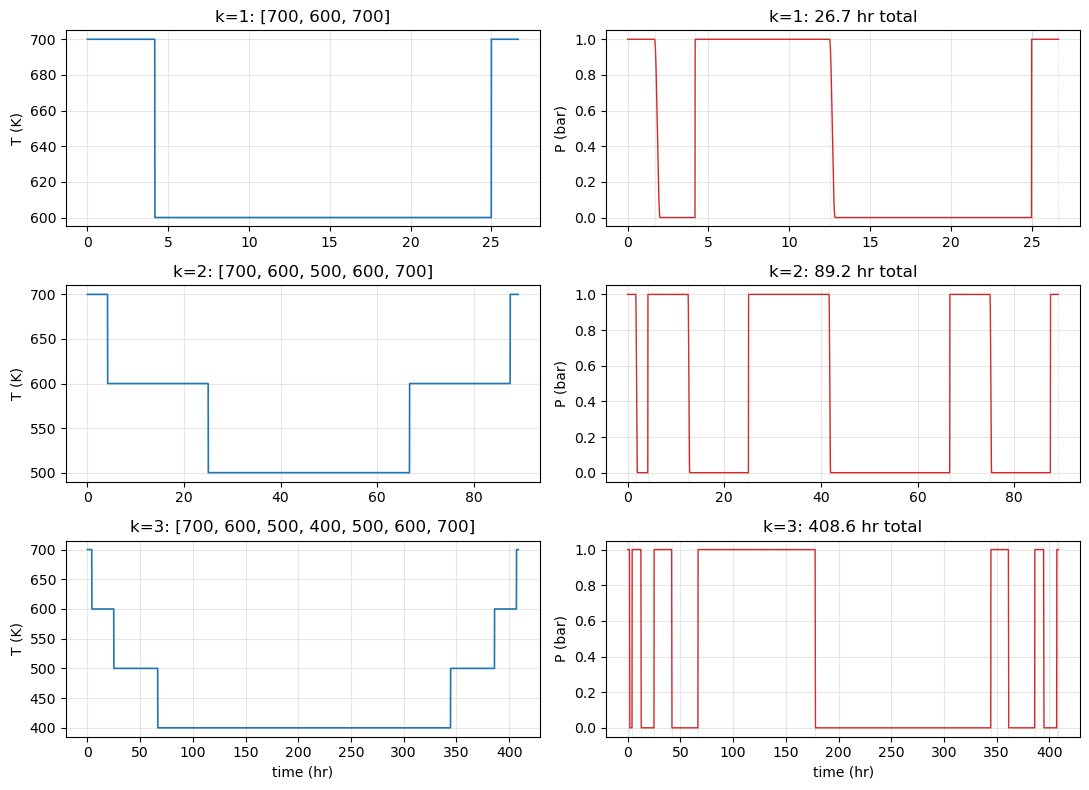

In [5]:
fig, ax = plt.subplots(3, 2, figsize=(11, 8.0), sharex=False)
for row, k in enumerate((1, 2, 3)):
    sd = SCHEDULES[k]
    sched = sd["sched"]; ft = sd["final_time"]; ms = sd["milestones"]
    T_func, _, P_py = make_callables(sched)

    t_plot = np.linspace(0, ft, 5000)
    T_plot = np.array([T_func(tt) for tt in t_plot])
    P_plot = np.array([P_py(tt)   for tt in t_plot])

    ax[row, 0].plot(t_plot / 3600, T_plot, "C0-", lw=1.2)
    ax[row, 0].set_ylabel("T (K)")
    ax[row, 0].grid(alpha=0.3)
    ax[row, 0].set_title(f"k={k}: {sd['temps']}")

    ax[row, 1].plot(t_plot / 3600, P_plot / 1e5, "C3-", lw=1.0)
    for m in ms:
        ax[row, 1].axvline(m / 3600, color="grey", ls=":", lw=0.5, alpha=0.5)
    ax[row, 1].set_ylabel("P (bar)")
    ax[row, 1].grid(alpha=0.3)
    ax[row, 1].set_title(f"k={k}: {ft/3600:.1f} hr total")

ax[2, 0].set_xlabel("time (hr)")
ax[2, 1].set_xlabel("time (hr)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "permeation_timelag_schedules.pdf"),
            bbox_inches="tight")
plt.show()


## 4. Solver wrappers

`run_festim` and `run_cheb` accept the schedule context explicitly so
the same function works for all three schedules. `max_stepsize` is now a
parameter so the same wrapper can do both the BE solve at `MAX_DT` and
the half-dt solve needed for Richardson extrapolation. `resample` and
`relative_l2` are the same helpers from `permeation_compare.ipynb`.


In [6]:
def resample(t, fl, t_grid):
    """Linear interpolation onto t_grid; clamp at the endpoints."""
    if len(t) == 0:
        return np.full_like(t_grid, np.nan)
    return np.interp(t_grid, t, fl, left=float(fl[0]), right=float(fl[-1]))


def relative_l2(test, ref):
    return float(np.linalg.norm(test - ref) / max(np.linalg.norm(ref), 1e-30))


def run_festim(n_cells, max_stepsize, sched, milestones, final_time,
               T_func, P_ufl):
    """FESTIM P1 with a graded uniform mesh; returns a result dict.

    Reports total wall, init wall, run wall, and Newton-only wall (the
    accumulator wraps `my.solver.solve` so it's the time spent inside
    Newton iterations only -- no init, no exports, no time-loop driver).
    """
    my = F.HydrogenTransportProblem()
    my.temperature = T_func

    s = np.linspace(0, 1, n_cells + 1)
    vertices = SUBSTRATE_THICK * s**2.0
    my.mesh = F.Mesh1D(vertices)

    tungsten = F.Material(D_0=D_0, E_D=E_D, K_S_0=K_S_0, E_K_S=E_K_S)

    H  = F.Species("H")
    T1 = F.Species("trap1", mobile=False)
    T2 = F.Species("trap2", mobile=False)
    e1 = F.ImplicitSpecies(n=N_TRAP1, others=[T1])
    e2 = F.ImplicitSpecies(n=N_TRAP2, others=[T2])
    my.species = [H, T1, T2]

    vol   = F.VolumeSubdomain1D(id=1, borders=(0, SUBSTRATE_THICK), material=tungsten)
    left  = F.SurfaceSubdomain1D(id=2, x=0)
    right = F.SurfaceSubdomain1D(id=3, x=SUBSTRATE_THICK)
    my.subdomains = [left, vol, right]

    my.boundary_conditions = [
        F.SievertsBC(subdomain=left, S_0=K_S_0, E_S=E_K_S, pressure=P_ufl, species=H),
        F.FixedConcentrationBC(species=H, subdomain=right, value=0),
    ]
    my.reactions = [
        F.Reaction(reactant=[H, e1], product=[T1],
                   k_0=K_0_TRAP, E_k=E_K_TRAP, p_0=P_0_TRAP, E_p=E_P_TRAP1, volume=vol),
        F.Reaction(reactant=[H, e2], product=[T2],
                   k_0=K_0_TRAP, E_k=E_K_TRAP, p_0=P_0_TRAP, E_p=E_P_TRAP2, volume=vol),
    ]

    my.settings = F.Settings(
        atol=1e0, rtol=1e-8, max_iterations=200, final_time=final_time,
    )
    my.settings.stepsize = F.Stepsize(
        initial_value=10, growth_factor=1.05, cutback_factor=0.5,
        max_stepsize=max_stepsize, target_nb_iterations=8,
        milestones=milestones,
    )

    flux = F.SurfaceFlux(field=H, surface=right)
    my.exports = [flux]

    err = None
    t_newton = 0.0
    t_init_wall = 0.0
    t_run_wall  = 0.0
    try:
        with open(os.devnull, "w") as dn, contextlib.redirect_stderr(dn):
            t_i0 = time.time()
            my.initialise()
            t_init_wall = time.time() - t_i0

            # Wrap the Newton solver to accumulate inner-loop time only.
            original_solve = my.solver.solve
            def _timed_solve(*args, **kwargs):
                nonlocal t_newton
                s0 = time.time()
                out = original_solve(*args, **kwargs)
                t_newton += time.time() - s0
                return out
            my.solver.solve = _timed_solve

            t_r0 = time.time()
            my.run()
            t_run_wall = time.time() - t_r0
    except Exception as e:
        err = type(e).__name__ + ": " + str(e)[:120]
    wall = t_init_wall + t_run_wall

    t_arr = np.asarray(flux.t)
    f_arr = np.abs(np.asarray(flux.data)) if len(flux.data) else np.array([])
    completed = (len(t_arr) > 0 and t_arr[-1] >= 0.95 * final_time and err is None)
    return {
        "method": "FESTIM", "param": n_cells, "dofs": n_cells + 1,
        "max_dt": max_stepsize,
        "wall": wall, "wall_init": t_init_wall, "wall_run": t_run_wall,
        "wall_newton": t_newton,
        "t": t_arr, "flux": f_arr,
        "ok": completed,
        "err": err if err else (None if completed else "incomplete"),
    }


def run_cheb(N, max_stepsize, sched, milestones, final_time, T_func, P_py):
    """Chebyshev pseudospectral; returns a result dict.

    Reports total / init / run / Newton-only wall time. Newton accumulator
    wraps `my._step` (the per-timestep Newton routine in chebyshev_festim,
    line 639) so it's symmetric with FESTIM's `my.solver.solve` wrap.
    """
    my = CF.HydrogenTransportProblem()
    my.temperature = T_func
    my.mesh = CF.ChebyshevMesh1D(N=N, x_max=SUBSTRATE_THICK, left_stretch=0.0)

    tungsten = CF.Material(D_0=D_0, E_D=E_D, K_S_0=K_S_0, E_K_S=E_K_S)

    H  = CF.Species("H")
    T1 = CF.Species("trap1", mobile=False)
    T2 = CF.Species("trap2", mobile=False)
    e1 = CF.ImplicitSpecies(n=N_TRAP1, others=[T1])
    e2 = CF.ImplicitSpecies(n=N_TRAP2, others=[T2])
    my.species = [H, T1, T2]

    vol   = CF.VolumeSubdomain1D(id=1, borders=(0, SUBSTRATE_THICK), material=tungsten)
    left  = CF.SurfaceSubdomain1D(id=2, x=0)
    right = CF.SurfaceSubdomain1D(id=3, x=SUBSTRATE_THICK)
    my.subdomains = [left, vol, right]

    my.boundary_conditions = [
        CF.SievertsBC(subdomain=left, S_0=K_S_0, E_S=E_K_S, pressure=P_py, species=H),
        CF.FixedConcentrationBC(species=H, subdomain=right, value=0.0),
    ]
    my.reactions = [
        CF.Reaction(reactant=[H, e1], product=[T1],
                    k_0=K_0_TRAP, E_k=E_K_TRAP, p_0=P_0_TRAP, E_p=E_P_TRAP1, volume=vol),
        CF.Reaction(reactant=[H, e2], product=[T2],
                    k_0=K_0_TRAP, E_k=E_K_TRAP, p_0=P_0_TRAP, E_p=E_P_TRAP2, volume=vol),
    ]

    my.settings = CF.Settings(
        atol=1e0, rtol=1e-8, max_iterations=200, final_time=final_time,
    )
    my.settings.stepsize = CF.Stepsize(
        initial_value=10, growth_factor=1.05, cutback_factor=0.5,
        max_stepsize=max_stepsize, target_nb_iterations=8,
        milestones=milestones,
        pre_milestone_duration=1, post_milestone_duration=1000,
    )

    flux = CF.SurfaceFlux(field=H, surface=right)
    my.exports = [flux]

    err = None
    t_step_acc = 0.0
    t_init_wall = 0.0
    t_run_wall  = 0.0
    try:
        t_i0 = time.time()
        my.initialise()
        t_init_wall = time.time() - t_i0

        original_step = my._step
        def _timed_step(*args, **kwargs):
            nonlocal t_step_acc
            s0 = time.time()
            out = original_step(*args, **kwargs)
            t_step_acc += time.time() - s0
            return out
        my._step = _timed_step

        t_r0 = time.time()
        my.run(verbose=False)
        t_run_wall = time.time() - t_r0
    except Exception as e:
        err = type(e).__name__ + ": " + str(e)[:120]
    wall = t_init_wall + t_run_wall

    t_arr = np.asarray(flux.t)
    f_arr = np.abs(np.asarray(flux.data)) if len(flux.data) else np.array([])
    completed = (len(t_arr) > 0 and t_arr[-1] >= 0.95 * final_time and err is None)
    return {
        "method": "Chebyshev", "param": N, "dofs": N + 1,
        "max_dt": max_stepsize,
        "wall": wall, "wall_init": t_init_wall, "wall_run": t_run_wall,
        "wall_newton": t_step_acc,
        "t": t_arr, "flux": f_arr,
        "ok": completed,
        "err": err if err else (None if completed else "incomplete"),
    }


## 5. Per-schedule sweep

For each `k` in (1, 2, 3): build two Chebyshev references at high N --
one at `MAX_DT/DT_REF_DIVISOR` (close-to-truth, for *total* error) and
one at `MAX_DT` (same time integrator as test runs, for *spatial-only*
error). Sweep both methods at `MAX_DT` only and compare each test point
against both references.

Why two references and no Richardson: the BE temporal error at `MAX_DT`
cancels in `relative_l2(test_BE, ref_BE_at_MAX_DT)` since both terms
share it, so the resulting curve is pure spatial discretization error,
no smoothness assumption on the time integrator needed (which Richardson
*does* require, and which the C2 kinks in the pressure ramp violate).
The fine-dt reference still appears as the "total error" series so the
two effects can be read off the same plot.

Each solver wrapper times `initialise()` and `run()` separately and
also accumulates Newton-only inner-loop time -- by wrapping
`my.solver.solve` for FESTIM and `my._step` for Chebyshev. The
efficiency-frontier panel uses the Newton-only number, so dolfinx form
compilation and per-step export overhead are excluded from the
comparison.

Mesh sweeps are intentionally short (5 points each). Realistic total
runtime is ~25-45 minutes end-to-end. To dial down for a smoke test,
comment out k=2 and k=3 in the loop below.

A FESTIM run that returns without raising but with rel-L2 above
`QUALITY_GATE` against the fine reference is a silent Newton blowup;
treat as failed and surface as a red `x` on the figure.



========== k=1  (final_time = 26.7 hr) ==========
  fine-dt reference: Cheb N+1=65 at dt=12.5 s ...
    wall = 6.6 s  (init 0.00, newton 6.58)  samples = 7766
  same-dt reference: Cheb N+1=65 at dt=200.0 s ...
    wall = 1.1 s  (init 0.00, newton 1.13)  BE plateau = 1.035e-02
  Cheb sweep: N+1 in [9, 13, 17, 25, 33] ...
    N+1=  9  wall=  0.4s  (init 0.00, newton 0.38)  ok=True
    N+1= 13  wall=  0.4s  (init 0.00, newton 0.39)  ok=True
    N+1= 17  wall=  0.4s  (init 0.00, newton 0.41)  ok=True
    N+1= 25  wall=  0.5s  (init 0.00, newton 0.46)  ok=True
    N+1= 33  wall=  0.5s  (init 0.00, newton 0.53)  ok=True
  FESTIM sweep: n_cells in (25, 50, 75, 100, 150) ...
    cells= 25  wall=   5.4s  (init  0.04, newton  2.72)  ok=True
    cells= 50  wall=   5.2s  (init  0.02, newton  2.60)  ok=True
    cells= 75  wall=   5.3s  (init  0.02, newton  2.66)  ok=True
    cells=100  wall=   4.6s  (init  0.02, newton  2.03)  ok=True
    cells=150  wall=   4.4s  (init  0.02, newton  1.85)  ok=Tru

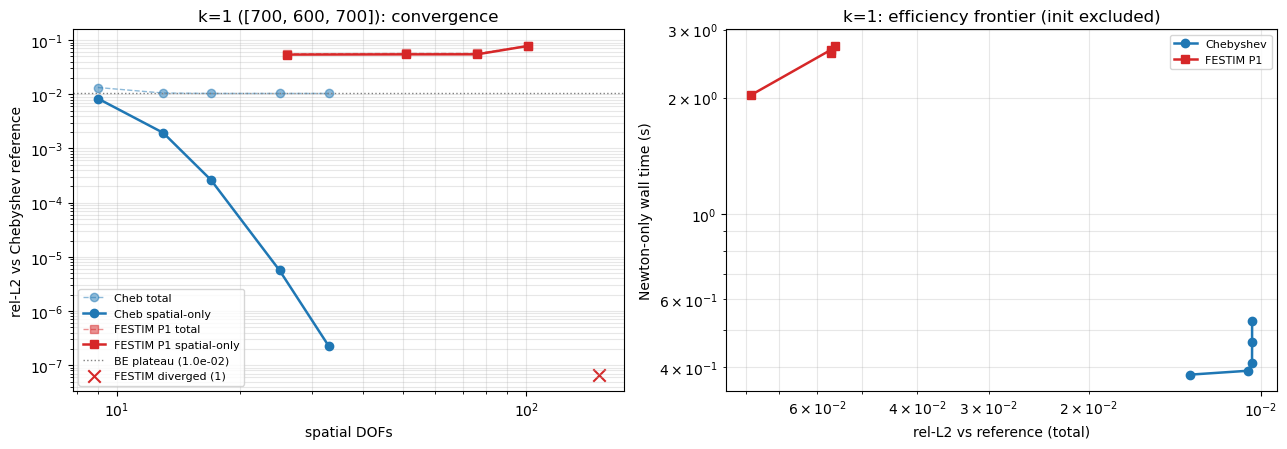


========== k=2  (final_time = 89.2 hr) ==========
  fine-dt reference: Cheb N+1=65 at dt=12.5 s ...
    wall = 18.9 s  (init 0.00, newton 18.72)  samples = 25854
  same-dt reference: Cheb N+1=65 at dt=200.0 s ...
    wall = 2.5 s  (init 0.00, newton 2.49)  BE plateau = 1.024e-02
  Cheb sweep: N+1 in [9, 13, 17, 25, 33] ...
    N+1=  9  wall=  0.8s  (init 0.00, newton 0.82)  ok=True
    N+1= 13  wall=  0.9s  (init 0.00, newton 0.88)  ok=True
    N+1= 17  wall=  0.9s  (init 0.00, newton 0.93)  ok=True
    N+1= 25  wall=  1.1s  (init 0.00, newton 1.05)  ok=True
    N+1= 33  wall=  1.2s  (init 0.00, newton 1.23)  ok=True
  FESTIM sweep: n_cells in (25, 50, 75, 100, 150) ...
    cells= 25  wall=  14.1s  (init  0.03, newton  6.93)  ok=True
    cells= 50  wall=  11.4s  (init  0.03, newton  4.40)  ok=True
    cells= 75  wall=  10.3s  (init  0.02, newton  3.29)  ok=True
    cells=100  wall=   9.3s  (init  0.02, newton  2.47)  ok=True
    cells=150  wall=   9.9s  (init  0.02, newton  2.89)  ok=

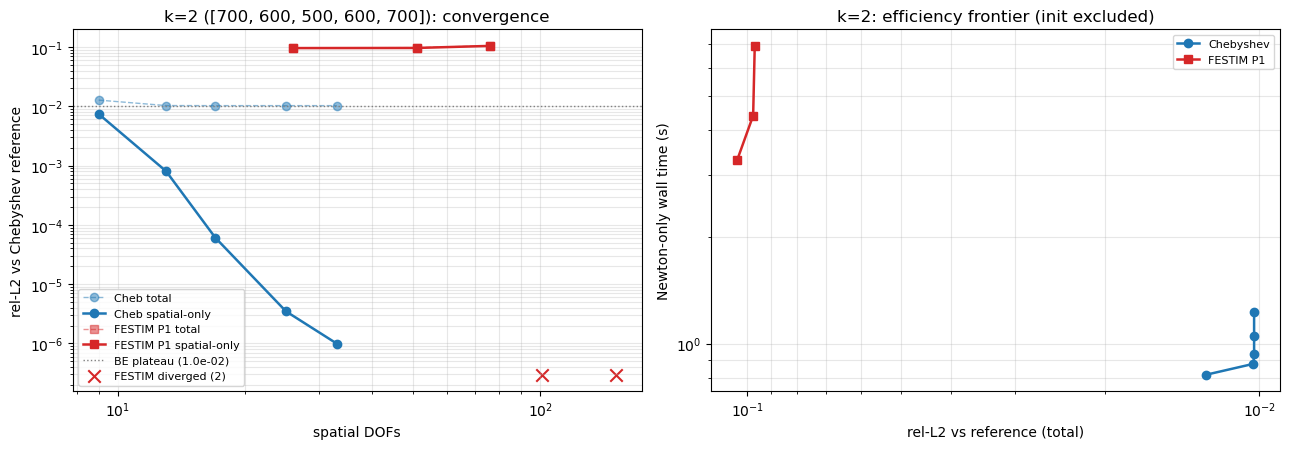


========== k=3  (final_time = 408.6 hr) ==========
  fine-dt reference: Cheb N+1=65 at dt=12.5 s ...
    wall = 74.5 s  (init 0.00, newton 73.48)  samples = 117942
  same-dt reference: Cheb N+1=65 at dt=200.0 s ...
    wall = 6.5 s  (init 0.00, newton 6.38)  BE plateau = 9.977e-03
  Cheb sweep: N+1 in [9, 13, 17, 25, 33] ...
    N+1=  9  wall=  2.3s  (init 0.00, newton 2.20)  ok=True
    N+1= 13  wall=  2.4s  (init 0.00, newton 2.33)  ok=True
    N+1= 17  wall=  2.5s  (init 0.00, newton 2.43)  ok=True
    N+1= 25  wall=  2.8s  (init 0.00, newton 2.78)  ok=True
    N+1= 33  wall=  3.1s  (init 0.00, newton 3.08)  ok=True
  FESTIM sweep: n_cells in (25, 50, 75, 100, 150) ...
    cells= 25  wall=  37.4s  (init  0.03, newton  8.89)  ok=True
    cells= 50  wall=  33.8s  (init  0.02, newton  5.26)  ok=True
    cells= 75  wall=  33.7s  (init  0.02, newton  5.83)  ok=True
    cells=100  wall=  36.6s  (init  0.02, newton  4.75)  ok=True
    cells=150  wall=  38.4s  (init  0.03, newton  7.62)  o

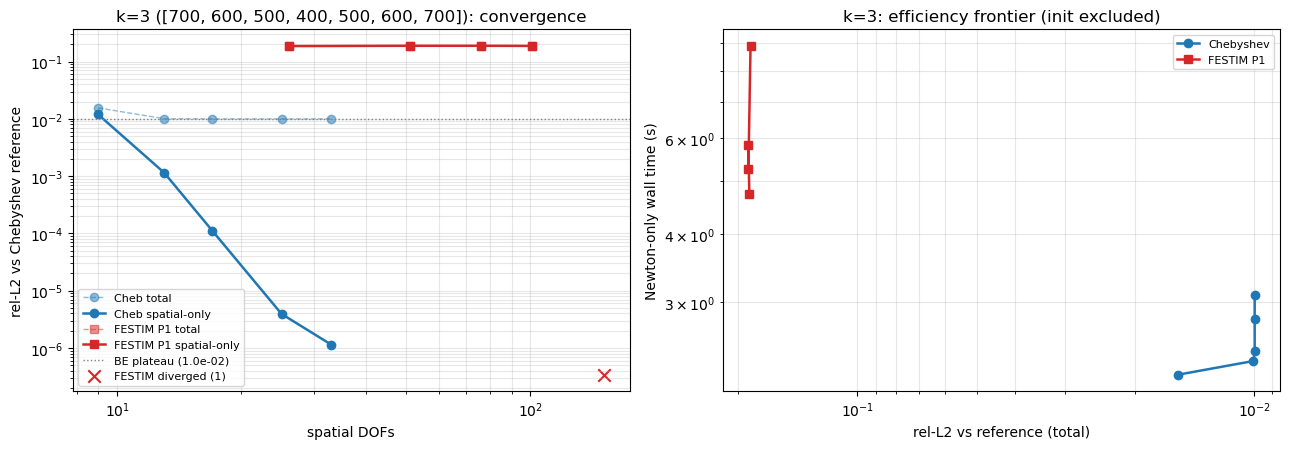

In [7]:
Ns_cheb     = (8, 12, 16, 24, 32)
n_cells_fes = (25, 50, 75, 100, 150)
N_REF       = 64


def _err_against(result, ref_resamp, t_obs):
    if not result["ok"]:
        return np.nan
    return relative_l2(resample(result["t"], result["flux"], t_obs),
                       ref_resamp)


def compute_errors(cheb_results, fes_results, flux_ref_total, flux_ref_be,
                   t_obs, gate=QUALITY_GATE):
    """For each test point produce a total error (vs fine-dt reference)
    and a spatial-only error (vs same-dt reference at high N). Carry
    Newton-only wall time alongside total wall so the efficiency frontier
    can plot the inner-loop work, with init excluded."""

    R = dict(
        dofs_cheb_ok=[],     wall_cheb_ok=[], wall_newton_cheb_ok=[],
        err_cheb_total=[],   err_cheb_spatial=[],
        dofs_fes_ok=[],      wall_fes_ok=[],  wall_newton_fes_ok=[],
        err_fes_total=[],    err_fes_spatial=[],
        fes_failed_dofs=[],  fes_failed_msgs=[],
        cheb_failed_dofs=[], cheb_failed_msgs=[],
    )

    def _process(results, dofs_key, wall_key, wall_newton_key,
                 err_total_key, err_spatial_key,
                 failed_dofs_key, failed_msgs_key):
        for r in results:
            dof = r["dofs"]
            err_total = _err_against(r, flux_ref_total, t_obs)
            ok = (r["ok"] and np.isfinite(err_total) and err_total <= gate)
            if ok:
                err_spatial = _err_against(r, flux_ref_be, t_obs)
                R[dofs_key].append(dof)
                R[wall_key].append(r["wall"])
                R[wall_newton_key].append(r.get("wall_newton", r["wall"]))
                R[err_total_key].append(err_total)
                R[err_spatial_key].append(err_spatial)
            else:
                R[failed_dofs_key].append(dof)
                R[failed_msgs_key].append(r.get("err") or
                                          f"silent (rel-L2={err_total:.2e})")

    _process(cheb_results,
             "dofs_cheb_ok", "wall_cheb_ok", "wall_newton_cheb_ok",
             "err_cheb_total", "err_cheb_spatial",
             "cheb_failed_dofs", "cheb_failed_msgs")
    _process(fes_results,
             "dofs_fes_ok", "wall_fes_ok", "wall_newton_fes_ok",
             "err_fes_total", "err_fes_spatial",
             "fes_failed_dofs", "fes_failed_msgs")
    return R


def plot_schedule_panels(k, R, be_plateau, sd):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

    if R["err_cheb_total"]:
        ax[0].loglog(R["dofs_cheb_ok"], R["err_cheb_total"], "o--",
                     color="C0", lw=1.0, alpha=0.5, label="Cheb total")
    if R["err_cheb_spatial"]:
        ax[0].loglog(R["dofs_cheb_ok"], R["err_cheb_spatial"], "o-",
                     color="C0", lw=1.8, label="Cheb spatial-only")
    if R["err_fes_total"]:
        ax[0].loglog(R["dofs_fes_ok"], R["err_fes_total"], "s--",
                     color="C3", lw=1.0, alpha=0.5, label="FESTIM P1 total")
    if R["err_fes_spatial"]:
        ax[0].loglog(R["dofs_fes_ok"], R["err_fes_spatial"], "s-",
                     color="C3", lw=1.8, label="FESTIM P1 spatial-only")
    if np.isfinite(be_plateau):
        ax[0].axhline(be_plateau, color="grey", ls=":", lw=1.0,
                      label=f"BE plateau ({be_plateau:.1e})")

    if R["fes_failed_dofs"]:
        floor = (min(R["err_cheb_spatial"]) * 0.3
                 if R["err_cheb_spatial"] else 1e-3)
        ax[0].scatter(R["fes_failed_dofs"],
                      [floor]*len(R["fes_failed_dofs"]),
                      marker="x", s=80, color="C3",
                      label=f"FESTIM diverged ({len(R['fes_failed_dofs'])})")

    ax[0].set_xlabel("spatial DOFs")
    ax[0].set_ylabel("rel-L2 vs Chebyshev reference")
    ax[0].set_title(f"k={k} ({sd['temps']}): convergence")
    ax[0].grid(alpha=0.3, which="both")
    ax[0].legend(fontsize=8, loc="best")

    if R["err_cheb_total"]:
        ax[1].loglog(R["err_cheb_total"], R["wall_newton_cheb_ok"], "o-",
                     color="C0", lw=1.8, label="Chebyshev")
    if R["err_fes_total"]:
        ax[1].loglog(R["err_fes_total"], R["wall_newton_fes_ok"], "s-",
                     color="C3", lw=1.8, label="FESTIM P1")

    ax[1].set_xlabel("rel-L2 vs reference (total)")
    ax[1].set_ylabel("Newton-only wall time (s)")
    ax[1].set_title(f"k={k}: efficiency frontier (init excluded)")
    ax[1].invert_xaxis()
    ax[1].grid(alpha=0.3, which="both")
    ax[1].legend(fontsize=8, loc="best")

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"permeation_timelag_k{k}.pdf"),
                bbox_inches="tight")
    plt.show()


RESULTS = {}
for k in (1, 2, 3):
    sd = SCHEDULES[k]
    sched, ms, ft = sd["sched"], sd["milestones"], sd["final_time"]
    T_func, P_ufl, P_py = make_callables(sched)
    t_obs = np.linspace(1.0, ft, 4000)
    print(f"\n========== k={k}  (final_time = {ft/3600:.1f} hr) ==========")

    print(f"  fine-dt reference: Cheb N+1={N_REF+1} at dt={MAX_DT/DT_REF_DIVISOR} s ...")
    ref_total = run_cheb(N=N_REF, max_stepsize=MAX_DT/DT_REF_DIVISOR,
                         sched=sched, milestones=ms, final_time=ft,
                         T_func=T_func, P_py=P_py)
    if not ref_total["ok"]:
        print(f"    REFERENCE FAILED ({ref_total['err']}); skipping k={k}")
        continue
    flux_ref_total = resample(ref_total["t"], ref_total["flux"], t_obs)
    print(f"    wall = {ref_total['wall']:.1f} s  "
          f"(init {ref_total['wall_init']:.2f}, "
          f"newton {ref_total['wall_newton']:.2f})  "
          f"samples = {len(ref_total['t'])}")

    print(f"  same-dt reference: Cheb N+1={N_REF+1} at dt={MAX_DT} s ...")
    ref_be = run_cheb(N=N_REF, max_stepsize=MAX_DT,
                      sched=sched, milestones=ms, final_time=ft,
                      T_func=T_func, P_py=P_py)
    if not ref_be["ok"]:
        print(f"    SAME-DT REFERENCE FAILED ({ref_be['err']}); skipping k={k}")
        continue
    flux_ref_be = resample(ref_be["t"], ref_be["flux"], t_obs)
    be_plateau = relative_l2(flux_ref_be, flux_ref_total)
    print(f"    wall = {ref_be['wall']:.1f} s  "
          f"(init {ref_be['wall_init']:.2f}, "
          f"newton {ref_be['wall_newton']:.2f})  "
          f"BE plateau = {be_plateau:.3e}")

    print(f"  Cheb sweep: N+1 in {[N+1 for N in Ns_cheb]} ...")
    cheb_results = []
    for N in Ns_cheb:
        r = run_cheb(N=N, max_stepsize=MAX_DT,
                     sched=sched, milestones=ms, final_time=ft,
                     T_func=T_func, P_py=P_py)
        cheb_results.append(r)
        print(f"    N+1={N+1:>3}  wall={r['wall']:5.1f}s  "
              f"(init {r['wall_init']:4.2f}, "
              f"newton {r['wall_newton']:4.2f})  ok={r['ok']}")

    print(f"  FESTIM sweep: n_cells in {n_cells_fes} ...")
    fes_results = []
    for nc in n_cells_fes:
        r = run_festim(n_cells=nc, max_stepsize=MAX_DT,
                       sched=sched, milestones=ms, final_time=ft,
                       T_func=T_func, P_ufl=P_ufl)
        fes_results.append(r)
        print(f"    cells={nc:>3}  wall={r['wall']:6.1f}s  "
              f"(init {r['wall_init']:5.2f}, "
              f"newton {r['wall_newton']:5.2f})  ok={r['ok']}")

    R = compute_errors(cheb_results, fes_results,
                       flux_ref_total, flux_ref_be, t_obs)
    R["be_plateau"] = be_plateau
    RESULTS[k] = R

    print(f"  -> Cheb points: {len(R['err_cheb_spatial'])}/{len(Ns_cheb)}, "
          f"FESTIM points: {len(R['err_fes_spatial'])}/{len(n_cells_fes)}, "
          f"FESTIM failures: {len(R['fes_failed_dofs'])}")

    plot_schedule_panels(k, R, be_plateau, sd)


## 6. Summary

For each schedule, the convergence panel shows two pairs of curves: a
*total* error (light, dashed) measured against a fine-dt Chebyshev
reference, and a *spatial-only* error (bold, solid) measured against a
same-dt high-N Chebyshev reference. The bold curves isolate spatial
discretization error because both sides of the rel-L2 share the BE
temporal error at `MAX_DT` and it cancels in the difference. The dashed
curves show what the user actually sees at `MAX_DT`, which is bounded
below by the BE plateau line.

Chebyshev's spatial-only curve falls exponentially with N until it
either hits the noise floor of the same-dt reference (rare on this
problem) or reveals that the reference itself isn't fully converged at
N=64. FESTIM P1's spatial-only curve falls at slope `O(h^2)` until the
mesh either fails Newton convergence outright (red x) or plateaus at a
structural offset that's independent of mesh density -- on this
problem, the candidate causes are FESTIM's one-sided `SurfaceFlux`
extraction and the H-vs-trap reaction coupling.

The wall-time panel restates the same comparison in cost-of-accuracy
form against total error -- which is what a user pays for at
`MAX_DT` -- so the efficiency frontier reflects practical use, not the
spatial-only diagnostic.
